# Data Interpolation and Imputation

This tutorial demonstrates data-wrangler's capabilities for handling missing data through interpolation and imputation techniques. These are essential for cleaning real-world datasets.

## Overview

Data-wrangler provides several approaches for handling missing data:

- **Interpolation**: Fill missing values using mathematical interpolation methods
- **Model-based imputation**: Use machine learning models to predict missing values  
- **Statistical imputation**: Fill with statistical measures (mean, median, mode)
- **Custom imputation**: Define your own missing data handling strategies

Let's explore these techniques with practical examples.

In [1]:
import datawrangler as dw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datawrangler.decorate import funnel, interpolate

## Interpolation with `@interpolate`

The `@interpolate` decorator cleans missing values (`NaN`) out of the data *before* your function runs.  You
control it at **call time** with the `interp_kwargs` keyword.  Passing `interp_kwargs={'method': 'linear'}`
fills gaps by linear interpolation (any method supported by `pandas.DataFrame.interpolate` works).

In [2]:
# Build a small signal and knock some values out
np.random.seed(0)
x = np.linspace(0, 4 * np.pi, 24)
signal = np.sin(x)

data = pd.DataFrame({'a': signal, 'b': np.cos(x), 'c': signal + np.random.randn(24) * 0.1})
data.loc[[3, 4, 5], 'a'] = np.nan
data.loc[[10, 11], 'b'] = np.nan
data.loc[[17], 'c'] = np.nan
print(f'Missing values before cleaning: {int(data.isna().sum().sum())}')
data.head(8)

Missing values before cleaning: 6


,a,b,c
0,0.000000,1.000000,0.176405
1,0.519584,0.854419,0.559600
2,0.887885,0.460065,0.985759
3,NaN,-0.068242,1.221758
4,NaN,-0.576680,1.003726
5,NaN,-0.917211,0.300673
6,-0.136167,-0.990686,-0.041158
7,-0.631088,-0.775711,-0.646224


In [3]:
from datawrangler.decorate import interpolate

@interpolate
def clean(df):
    """Return the data unchanged; @interpolate fills the gaps before we ever see it."""
    return df

# Linear interpolation
interpolated = clean(data, interp_kwargs={'method': 'linear'})
print(f'Missing values after linear interpolation: {int(interpolated.isna().sum().sum())}')
interpolated.head(8)

Missing values after linear interpolation: 0


,a,b,c
0,0.000000,1.000000,0.176405
1,0.519584,0.854419,0.559600
2,0.887885,0.460065,0.985759
3,0.631872,-0.068242,1.221758
4,0.375859,-0.576680,1.003726
5,0.119846,-0.917211,0.300673
6,-0.136167,-0.990686,-0.041158
7,-0.631088,-0.775711,-0.646224


## Model-based imputation

Instead of interpolating along each column, you can **impute** missing entries with a scikit-learn model that
learns from the relationships *between* columns.  Pass an `impute_kwargs` dictionary (nested inside
`interp_kwargs`) naming the model, e.g. `IterativeImputer`, `KNNImputer`, or `SimpleImputer`.

In [4]:
# Iterative imputation: model each column from the others
iterative = clean(data, interp_kwargs={'impute_kwargs': {'model': 'IterativeImputer'}})
print(f'Missing values after IterativeImputer: {int(iterative.isna().sum().sum())}')

# Simple imputation: fill each column with its mean (see config.ini for the default strategy)
simple = clean(data, interp_kwargs={'impute_kwargs': {'model': 'SimpleImputer'}})
print(f'Missing values after SimpleImputer:    {int(simple.isna().sum().sum())}')
iterative.head(8)

Missing values after IterativeImputer: 0
Missing values after SimpleImputer:    0


,a,b,c
0,0.000000,1.000000,0.176405
1,0.519584,0.854419,0.559600
2,0.887885,0.460065,0.985759
3,1.102661,-0.068242,1.221758
4,0.899463,-0.576680,1.003726
5,0.243019,-0.917211,0.300673
6,-0.136167,-0.990686,-0.041158
7,-0.631088,-0.775711,-0.646224


## Comparing the approaches

Interpolation uses each column's own trend, while imputation models relationships across columns.  Plotting
the filled values for column `a` shows how the strategies differ where the data were missing (rows 3-5).

Values filled in for the missing rows of column "a":
   linear interpolation  IterativeImputer  SimpleImputer
3              0.631872          1.102661      -0.105383
4              0.375859          0.899463      -0.105383
5              0.119846          0.243019      -0.105383


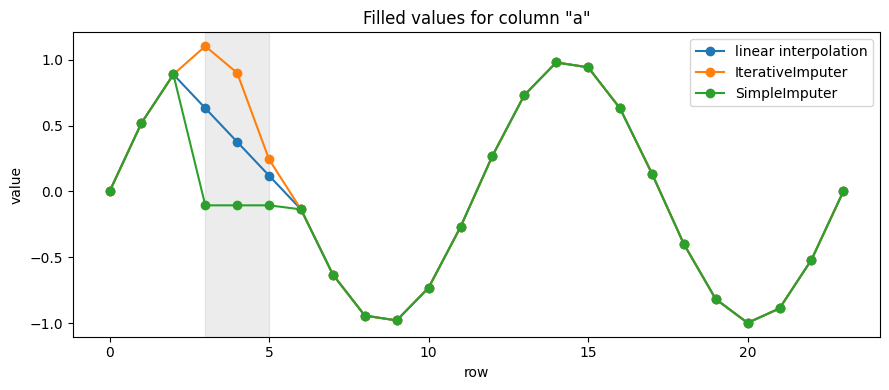

In [5]:
missing_rows = [3, 4, 5]
comparison = pd.DataFrame({
    'linear interpolation': interpolated['a'],
    'IterativeImputer': iterative['a'],
    'SimpleImputer': simple['a'],
})
print('Values filled in for the missing rows of column "a":')
print(comparison.loc[missing_rows])

ax = comparison.plot(marker='o', figsize=(9, 4), title='Filled values for column "a"')
ax.axvspan(missing_rows[0], missing_rows[-1], alpha=0.15, color='gray')
ax.set_xlabel('row')
ax.set_ylabel('value')
plt.tight_layout()
plt.show()